I0000 00:00:1789876060.208242      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789876060.211449      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



[INFO] Memulai Training: Scenario_RGB_QF95 (140k Dataset, Epoch 50)
Epoch 1/50
3063/3063 ━━━━━━━━━━━━━━━━━━━━ 590s 190ms/step - accuracy: 0.5101 - loss: 1.1722 - val_accuracy: 0.5047 - val_loss: 0.9295 - learning_rate: 1.0000e-04
Epoch 2/50
3063/3063 ━━━━━━━━━━━━━━━━━━━━ 455s 149ms/step - accuracy: 0.5423 - loss: 0.8422 - val_accuracy: 0.5300 - val_loss: 0.7785 - learning_rate: 1.0000e-04
Epoch 3/50
3063/3063 ━━━━━━━━━━━━━━━━━━━━ 452s 147ms/step - accuracy: 0.5903 - loss: 0.7383 - val_accuracy: 0.5522 - val_loss: 0.7292 - learning_rate: 1.0000e-04
Epoch 4/50
3063/3063 ━━━━━━━━━━━━━━━━━━━━ 453s 148ms/step - accuracy: 0.6706 - loss: 0.6625 - val_accuracy: 0.7079 - val_loss: 0.6134 - learning_rate: 1.0000e-04
Epoch 5/50
3063/3063 ━━━━━━━━━━━━━━━━━━━━ 453s 148ms/step - accuracy: 0.7300 - loss: 0.5995 - val_accuracy: 0.7571 - val_loss: 0.5510 - learning_rate: 1.0000e-04
Epoch 6/50
3063/3063 ━━━━━━━━━━━━━━━━━━━━ 451s 147ms/step - accuracy: 0.7558 - loss: 0.5641 - val_accuracy: 0.7793 - val_

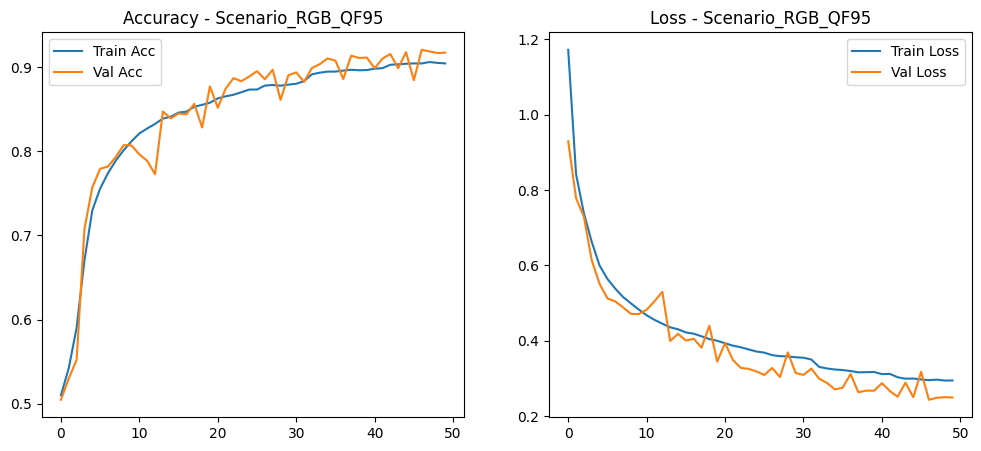

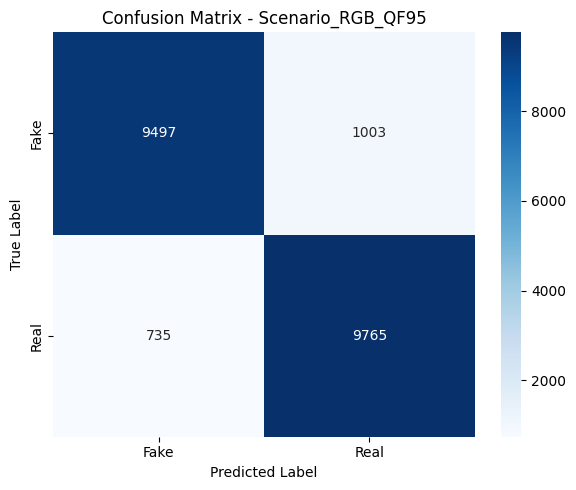

In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
from PIL import Image, ImageChops, ImageEnhance
from io import BytesIO
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D, Dense, Dropout, LeakyReLU, RandomFlip, RandomRotation, RandomZoom, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import regularizers
import random

# ==============================================================================
# 1. KONFIGURASI SKENARIO (UBAH 2 VARIABEL INI UNTUK 15 SKENARIO BERBEDA)
# ==============================================================================
# Pilihan SCENARIO_TYPE: 'RGB', 'ELA', 'CLAHE', 'SRM', 'FUSION'
SCENARIO_TYPE = 'RGB' 

# Pilihan TARGET_QF: 95, 75, atau 50
TARGET_QF = 95        

# Penamaan Otomatis
SCENARIO_NAME = f"Scenario_{SCENARIO_TYPE}_QF{TARGET_QF}"
OUTPUT_DIR = f"/kaggle/working/{SCENARIO_NAME}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- SEEDING UNTUK REPRODUSIBILITAS ---
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

IMG_SIZE = 256
BATCH_SIZE = 32

# ==============================================================================
# 2. PERSIAPAN DATA (FULL 140k Tanpa Sampling)
# ==============================================================================
def find_dataset_path(base_dir='/kaggle/input'):
    for root, dirs, files in os.walk(base_dir):
        if all(split in dirs for split in ['train', 'valid', 'test']):
            return root
    raise FileNotFoundError("Dataset 140k Real and Fake Faces tidak ditemukan.")

DATASET_PATH = find_dataset_path()

def load_all_paths(base_path):
    fake_paths, real_paths = [], []
    for split in ['train', 'valid', 'test']:
        split_dir = os.path.join(base_path, split)
        if os.path.exists(split_dir):
            for class_name in ['fake', 'real']:
                class_dir = os.path.join(split_dir, class_name)
                if os.path.exists(class_dir):
                    for img_name in os.listdir(class_dir):
                        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                            path = os.path.join(class_dir, img_name)
                            if class_name == 'fake': fake_paths.append(path)
                            else: real_paths.append(path)
    labels = [0] * len(fake_paths) + [1] * len(real_paths)
    filepaths = fake_paths + real_paths
    combined = list(zip(filepaths, labels))
    random.shuffle(combined)
    return np.array([x[0] for x in combined]), np.array([x[1] for x in combined])

filepaths, labels = load_all_paths(DATASET_PATH)

# Stratified Split 70:15:15 untuk mencegah kebocoran data
X_train, X_temp, y_train, y_temp = train_test_split(filepaths, labels, test_size=0.30, stratify=labels, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

# ==============================================================================
# 3. FUNGSI DEGRADASI KOMPRESI & PRAPEMROSESAN (On-The-Fly)
# ==============================================================================
def apply_jpeg_compression(img_bgr, qf):
    img_pil = Image.fromarray(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    buffer = BytesIO()
    img_pil.save(buffer, format="JPEG", quality=qf)
    buffer.seek(0)
    img_compressed = np.array(Image.open(buffer))
    return cv2.cvtColor(img_compressed, cv2.COLOR_RGB2BGR)

def process_pipeline(filepath_tensor, label):
    path_str = filepath_tensor.numpy().decode('utf-8')
    img_bgr = cv2.imread(path_str)
    if img_bgr is None:
        raise ValueError(f"Gagal membaca: {path_str}")
        
    # INJEKSI DEGRADASI KOMPRESI (Sesuai Batasan Masalah CRISP-DM)
    img_bgr = apply_jpeg_compression(img_bgr, TARGET_QF)

    if SCENARIO_TYPE == 'RGB':
        res = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        res = cv2.resize(res, (IMG_SIZE, IMG_SIZE))
        res = res.astype('float32') / 255.0
        return res, tf.cast(label, tf.int32)
        
    elif SCENARIO_TYPE == 'ELA':
        cv2.imwrite('/tmp/temp.jpg', img_bgr, [cv2.IMWRITE_JPEG_QUALITY, 90])
        img_compressed = cv2.imread('/tmp/temp.jpg')
        diff = cv2.absdiff(img_bgr, img_compressed)
        gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
        res = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX)
        res = np.expand_dims(cv2.resize(res, (IMG_SIZE, IMG_SIZE)), axis=-1).astype('float32') / 255.0
        return res, tf.cast(label, tf.int32)
        
    elif SCENARIO_TYPE == 'CLAHE':
        lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        res = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(l)
        res = np.expand_dims(cv2.resize(res, (IMG_SIZE, IMG_SIZE)), axis=-1).astype('float32') / 255.0
        return res, tf.cast(label, tf.int32)
        
    elif SCENARIO_TYPE == 'SRM':
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        kernel = np.array([[-1, 2, -2, 2, -1], [2, -6, 8, -6, 2], [-2, 8, -12, 8, -2], [2, -6, 8, -6, 2], [-1, 2, -2, 2, -1]]) / 12.0
        res = cv2.filter2D(gray, cv2.CV_32F, kernel)
        res = cv2.normalize(np.abs(res), None, 0, 255, cv2.NORM_MINMAX)
        res = np.expand_dims(cv2.resize(res, (IMG_SIZE, IMG_SIZE)), axis=-1).astype('float32') / 255.0
        return res, tf.cast(label, tf.int32)

def create_dataset(paths, labels, is_training=True):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if is_training:
        dataset = dataset.shuffle(10000, reshuffle_each_iteration=True)
        
    channel_dim = 3 if SCENARIO_TYPE == 'RGB' else 1
    dataset = dataset.map(
        lambda x, y: tf.py_function(process_pipeline, [x, y], [tf.float32, tf.int32]),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    dataset = dataset.map(lambda x, y: (tf.ensure_shape(x, (IMG_SIZE, IMG_SIZE, channel_dim)), tf.ensure_shape(y, ())))
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = create_dataset(X_train, y_train, True)
val_ds = create_dataset(X_val, y_val, False)
test_ds = create_dataset(X_test, y_test, False)

# ==============================================================================
# 4. ARSITEKTUR MESONET (Teroptimasi Anti-Overfitting & Efisiensi GAP)
# ==============================================================================
def build_mesonet_branch(input_shape, name_prefix):
    inputs = Input(shape=input_shape, name=f'{name_prefix}_input')
    x = RandomFlip("horizontal")(inputs)
    
    # Menonaktifkan rotasi pada ELA untuk menjaga struktur grid 8x8 JPEG
    if SCENARIO_TYPE != 'ELA':
        x = RandomRotation(0.05)(x)
        x = RandomZoom(0.05)(x)
        
    l2_reg = regularizers.l2(0.01) # L2 Kuat untuk mencegah model collapse
    
    x = Conv2D(8, (3, 3), padding='same', activation='relu', kernel_regularizer=l2_reg)(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(8, (5, 5), padding='same', activation='relu', kernel_regularizer=l2_reg)(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(16, (5, 5), padding='same', activation='relu', kernel_regularizer=l2_reg)(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(16, (5, 5), padding='same', activation='relu', kernel_regularizer=l2_reg)(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((4, 4), padding='same')(x)
    
    x = GlobalAveragePooling2D(name=f'{name_prefix}_GAP')(x)
    return inputs, x

channel = 3 if SCENARIO_TYPE == 'RGB' else 1
inputs, x = build_mesonet_branch((IMG_SIZE, IMG_SIZE, channel), SCENARIO_TYPE)

x = Dropout(0.5)(x)
x = Dense(16, kernel_regularizer=regularizers.l2(0.01))(x)
x = LeakyReLU(negative_slope=0.1)(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=inputs, outputs=outputs, name=f"MesoNet_GAP_{SCENARIO_TYPE}")
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# ==============================================================================
# 5. PELATIHAN & EKSPOR VISUALISASI
# ==============================================================================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint(os.path.join(OUTPUT_DIR, 'best_model.keras'), monitor='val_accuracy', save_best_only=True)
]

print(f"\n[INFO] Memulai Training: {SCENARIO_NAME} (140k Dataset, Epoch 50)")
history = model.fit(train_ds, validation_data=val_ds, epochs=50, callbacks=callbacks)

# Visualisasi
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title(f'Accuracy - {SCENARIO_NAME}')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title(f'Loss - {SCENARIO_NAME}')
plt.legend()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=300)

# Confusion Matrix
y_true, y_preds = [], []
for imgs, labels in test_ds:
    preds = (model.predict(imgs, verbose=0) > 0.5).astype(int).flatten()
    y_preds.extend(preds)
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title(f'Confusion Matrix - {SCENARIO_NAME}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=300)

with open(os.path.join(OUTPUT_DIR, 'metrics.txt'), 'w') as f:
    f.write(classification_report(y_true, y_preds, target_names=['Fake', 'Real']))
print(f"\n[SUCCESS] Artefak evaluasi disimpan di {OUTPUT_DIR}")